### Task 2: Jets as graphs
In this notebook we build a **Graph Neural Network (GNN)** classifier to distinguish **quark jets** from **gluon jets** using the publicly available quark-gluon dataset.

The `pipeline` has four stages:

1. **Image → Point cloud** — extract only the non-zero pixels from each 125×125×3 calorimeter image, discarding empty space  
2. **Point cloud → Graph** — connect nearby points with k-nearest-neighbor edges to build a `torch_geometric` `Data` object  
3. **GNN training** — train a **GraphSAGE** model to classify each graph as quark (1) or gluon (0)  
4. **Evaluation** — measure performance with ROC-AUC, confusion matrix, and loss curves

### Install Dependencies
- **`torch_geometric`** — the main PyG library providing graph data structures, loaders, and GNN layers  
- **`torch_cluster`** — provides efficient k-nearest-neighbor graph construction (`knn_graph`) used later when building edges


In [ ]:
!pip install torch_geometric
!pip install torch_cluster

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_cluster: filename=torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl size=2242639 sha256=aea08ca23c42f01bf517ae2664cba7066cd942c88abf3b3a346edc77bc274d9b
  Stored in directory: /root/.cache/pip/wheels/2e/8f/d0/13408a84825c9a587151a74727b4a6d47ec67e0d625b385ad7
Successfully built torch_cluster


### 1. Imports

Key libraries and what each is used for:

| Library | Role |
|---|---|
| `h5py` | Read the `.hdf5` dataset file |
| `torch_geometric` | Graph data (`Data`), mini-batch loader (`DataLoader`), GNN layers (`SAGEConv`, `global_mean_pool`) |
| `torch_cluster` | Fast kNN graph construction |
| `sklearn.metrics` | `roc_auc_score`, `f1_score`, `accuracy_score` for evaluation |
| `tqdm` | Progress bars during training |


In [ ]:
import os
import math
import h5py
import numpy as np
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch.utils.data import random_split

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import torch_cluster

In [ ]:
data = h5py.File("/content/drive/MyDrive/ML4SCI/quark-gluon_data-set_n139306.hdf5", mode = "r")

In [ ]:
# set the variables with values for the model & data
seed = 42
subset_size = 100000
MAX_NODES = 400
k_neighbors = 6
BATCH_SIZE = 32
dropout = 0.03
lr = 1e-3
num_epochs = 10


In [ ]:
list(data)

['X_jets', 'm0', 'pt', 'y']

In [ ]:
X_jets = np.array(data["X_jets"][:subset_size])
m0 = np.array(data["m0"][:subset_size])
pt = np.array(data["pt"][:subset_size])
label = np.array(data["y"][:subset_size])

In [ ]:
X_jets.shape

(20000, 125, 125, 3)

### Step 1: Image -> Point Cloud

#### Why a point cloud?

Each jet image is **very sparse**,  most of the 125×125 pixels are zero. A CNN must process the entire dense grid regardless. By extracting only the **non-zero pixels**, we discard the empty space and represent each jet as a compact set of active detector cells — this is the *point cloud*.

#### How it works

The function `Jets_to_Point_Cloud` iterates over all 3 channels. For every non-zero pixel `(row Y, col X)` in each channel it creates a 4-dimensional point:

```
point = [X / (W-1),   normalised x-coordinate  ∈ [0, 1]
         Y / (H-1),    normalised y-coordinate  ∈ [0, 1]
         pixel_value,  energy deposit (raw intensity)
         channel_id]  ←which detector (0=HCAL, 1=ECAL, 2=Tracks)
```

If the resulting cloud has **more than `MAX_NODES` points**, we keep only the top-400 by intensity — preserving the most energetically significant deposits, which carry the most discriminating information for quark vs gluon separation.

In [ ]:
def Jets_to_Point_Cloud(jet, max_nodes = MAX_NODES):
  """
  This function convert one jet image to a point in a cloud.

  paramaters:
    jet (np.ndarray) : jet image of shape (125, 125, 3)
    max_node (int) : Maximum number of points to keep in a cloud

  Returns:
    np.ndarray: point cloud of shape (num_points, 4)
                columns = [x_norm, y_norm, intensity, channel]
  """
  H, W, C = jet.shape
  points = []

  for ch in range(C):
    channel_img = jet[:, :, ch]
    Y, X = np.nonzero(channel_img > 0) # To take all the non-zero pixels in a jet

    for Y1, X1 in zip(Y, X):
      value_pixel = channel_img[Y1, X1]
      points.append([
          # Normalizing all the values
          X1 / (W -1),
          Y1 / (H-1),
          float(value_pixel),
          float(ch)
      ])
  # Handling zero values
  if len(points) == 0:
    return np.array([[0.0, 0.0, 0.0, 0.0]])

  # Convert the points array to np.ndarray
  points = np.array(points)

  # check if point in the cloud is bigger than the max nodes
  if len(points) > max_nodes:
    order = np.argsort(points[:, 2])[::-1]  # sort the points by their intensity
    points = points[order[:max_nodes]] # keeping the biggest points in the cloud
  return points

In [ ]:
Jets = X_jets[0]
points = Jets_to_Point_Cloud(Jets,
                             max_nodes = MAX_NODES)

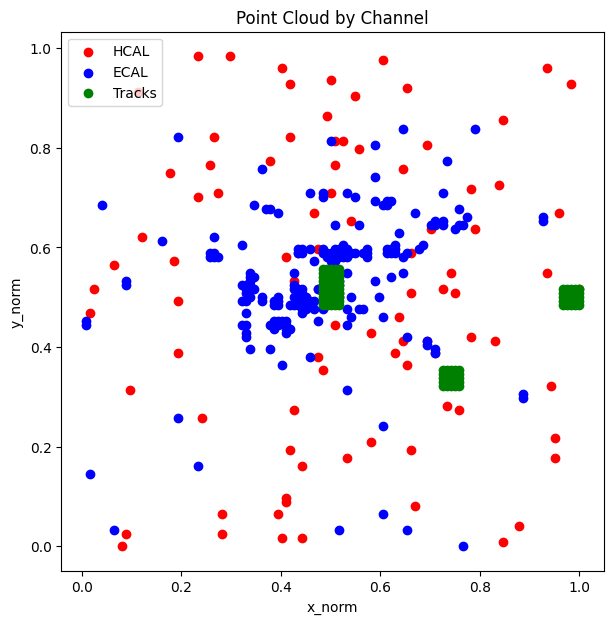

In [ ]:
# visualize the scatter of the channels
channel_names = {0: "HCAL", 1: "ECAL", 2: "Tracks"}
colors = {0: "red", 1: "blue", 2: "green"}

plt.figure(figsize=(7,7))
for ch in [0, 1, 2]:
    mask = points[:, 3] == ch
    plt.scatter(
        points[mask, 0],
        points[mask, 1],
        c=colors[ch],
        label=channel_names[ch]
        )

plt.xlabel("x_norm")
plt.ylabel("y_norm")
plt.title("Point Cloud by Channel")
plt.legend()
plt.show()

### Step 2:   Point Cloud -> Graph

#### Graph representation choices

| Component | Choice | Justification |
|---|---|---|
| **Nodes** | Each non-zero pixel (up to 400) | Natural particles / energy deposits |
| **Node features** | `[x_norm, y_norm, intensity, channel]` | Position encodes shower geometry; intensity and channel encode energy type |
| **Edges** | k-Nearest Neighbors in (x, y) space, k=8 | Nearby deposits likely share a common shower origin — local geometry is physically meaningful |
| **Edge direction** | Bidirectional (both `i→j` and `j→i`) | Makes the graph undirected, so messages flow symmetrically |

#### kNN edge construction

`knn_edge_index` computes pairwise Euclidean distances in the 2D position space `(x_norm, y_norm)` and returns edges connecting each node to its 8 closest neighbours. The reverse edges are concatenated so information can propagate in both directions during message passing.

`point_cloud_to_graph` wraps this into a `torch_geometric.data.Data` object with:
- `data.x` — node feature matrix, shape `(N_nodes, 4)`
- `data.edge_index` — COO-format edge list, shape `(2, N_edges)`
- `data.y` — graph-level label (0 or 1)


In [ ]:
import torch
from torch_geometric.data import Data

def knn_edge_index(position, k=8):
    """
    Build k-nearest-neighbor edges from node positions.

    Parameters:
        position (torch.Tensor): Node positions of shape (num_nodes, 2)
        k (int): Number of neighbors

    Returns:
        torch.Tensor: edge_index of shape (2, num_edges)
    """
    num_nodes = position.size(0)

    if num_nodes == 1:
        return torch.tensor([[0], [0]], dtype=torch.long)

    k = min(k, num_nodes - 1)
    dist = torch.cdist(position, position, p=2)
    dist.fill_diagonal_(float("inf"))

    nn_idx = torch.topk(dist, k=k, largest=False).indices

    row = torch.arange(num_nodes).view(-1, 1).repeat(1, k).reshape(-1)
    col = nn_idx.reshape(-1)

    edge_index = torch.stack([row, col], dim=0)
    rev_edge_index = torch.stack([col, row], dim=0)

    return torch.cat([edge_index, rev_edge_index], dim=1)

from torch_geometric.data import Data
from torch_geometric.nn import knn_graph

def point_cloud_to_graph(points, label, k=8):
    """
    Convert one point cloud into a graph.

    Parameters:
        points (np.ndarray): Point cloud of shape (num_points, 4)
        label (float): Graph label (0 for gluon, 1 for quark)
        k (int): Number of neighbors

    Returns:
        Data: PyTorch Geometric graph object
    """
    x = torch.tensor(points, dtype=torch.float32)
    pos = x[:, :2]
    edge_index = knn_graph(pos, k=min(k, pos.size(0)-1), loop=False)
    y = torch.tensor([label], dtype=torch.float32)
    return Data(x=x, edge_index=edge_index, y=y)

In [ ]:
point_cloud_to_graph(points= points,
                     label= 1.0)

Data(x=[400, 4], edge_index=[2, 3200], y=[1])

In [ ]:
jet = X_jets[0]
points = Jets_to_Point_Cloud(jet, max_nodes=400)
graph = point_cloud_to_graph(points, label[0], k=8)

print("Jet shape:", jet.shape)
print("Points shape:", points.shape)
print("Graph:", graph)
print("Graph x shape:", graph.x.shape)
print("Graph edge_index shape:", graph.edge_index.shape)
print("Graph label:", graph.y)

Jet shape: (125, 125, 3)
Points shape: (400, 4)
Graph: Data(x=[400, 4], edge_index=[2, 3200], y=[1])
Graph x shape: torch.Size([400, 4])
Graph edge_index shape: torch.Size([2, 3200])
Graph label: tensor([0.])


In [ ]:
graphs = []
for i in range(len(X_jets)):
  points = Jets_to_Point_Cloud(X_jets[i])
  graph = point_cloud_to_graph(points,
                               label[i])
  graphs.append(graph)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
indices = np.arange(len(graphs))

# Split the training and temp graphs
train_idx, temp_idx = train_test_split(indices,
                              test_size=0.25,
                              stratify = label)

val_idx, test_idx = train_test_split(temp_idx,
                                           test_size= 0.4,
                                           stratify = label[temp_idx])

train_graphs = [graphs[i] for i in train_idx]
val_graphs = [graphs[i] for i in val_idx]
test_graphs = [graphs[i] for i in test_idx]

print("Training graphs:", len(train_graphs))
print("Val graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))

Training graphs: 75000
Val graphs: 15000
Test graphs: 10000


In [ ]:
# Turn the graphs into dataloader
train_graphs_loader = DataLoader(train_graphs,
                                 batch_size = BATCH_SIZE,
                                 shuffle = True)

val_graphs_loader = DataLoader(val_graphs,
                               batch_size = BATCH_SIZE,
                               shuffle = False)

test_graphs_loader = DataLoader(test_graphs,
                          batch_size = BATCH_SIZE,
                          shuffle = False)


### Model --> JetGraphSAGE

#### Why GraphSAGE?

 We adopt the **GraphSAGE-based** graph representation proposed by Hariri et al. (2021), which uses kNN graphs over detector hits with spatial coordinates and energy as node features. adapting their encoder architecture for the binary quark/gluon classification task by replacing the VAE decoder with a global mean pooling layer followed by a fully connected classifier.

#### Architecture

```
Input (4 features per node)
    ↓
SAGEConv(4 → 128)  + ReLU   
    ↓
SAGEConv(128 → 256) + ReLU   
    ↓
SAGEConv(256 → 256) + ReLU   
    ↓
global_mean_pool               
    ↓
Linear(256 → 128) + ReLU     
    ↓
Linear(128 → 1)              
```

The final logit is passed through `BCEWithLogitsLoss` during training.


In [ ]:
input_features = 4
hidden_features = 128
from torch import nn

class JetGraphSAGE(nn.Module):
  def __init__(self,
               input_features,
               hidden_features):
    super().__init__()

    self.conv1 = SAGEConv(in_channels= input_features,
                          out_channels= hidden_features)

    self.conv2 = SAGEConv(in_channels = hidden_features,
                          out_channels = hidden_features*2)

    self.conv3 = SAGEConv(in_channels = hidden_features* 2,
                          out_channels = hidden_features* 2)

    self.lin1 = nn.Linear(hidden_features* 2, hidden_features)
    self.lin2 = nn.Linear(hidden_features, 1)

  def forward(self, x, edge_index, batch):
    x = self.conv1(x, edge_index)
    x = F.relu(x)

    x = self.conv2(x, edge_index)
    x = F.relu(x)

    x = self.conv3(x, edge_index)
    x = F.relu(x)

    x = global_mean_pool(x, batch= batch)

    x = self.lin1(x)
    x = F.relu(x)

    x = self.lin2(x)

    return x.view(-1)


In [ ]:
#set the device for models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
#
model = JetGraphSAGE(input_features= input_features,
                     hidden_features= hidden_features).to(device)
print(model)
# initalize the loss and the optimization function
criterion = nn.BCEWithLogitsLoss()
optimization = torch.optim.Adam(params = model.parameters(),
                                lr = 0.001)

Device: cuda
JetGraphSAGE(
  (conv1): SAGEConv(4, 128, aggr=mean)
  (conv2): SAGEConv(128, 256, aggr=mean)
  (conv3): SAGEConv(256, 256, aggr=mean)
  (lin1): Linear(in_features=256, out_features=128, bias=True)
  (lin2): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
num_epochs = 10

train_losses = []
val_losses = []
for epoch in range(1, num_epochs + 1):
    model.train()
    total_train_loss = 0

    for batch in train_graphs_loader:
        batch = batch.to(device)

        optimization.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.view(-1).float())
        loss.backward()
        optimization.step()

        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_graphs_loader)
    train_losses.append(avg_train_loss)


    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_graphs_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.view(-1).float())
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_graphs_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/10 | Train Loss: 0.5460 | Val Loss: 0.5529
Epoch 2/10 | Train Loss: 0.5461 | Val Loss: 0.5509
Epoch 3/10 | Train Loss: 0.5460 | Val Loss: 0.5481
Epoch 4/10 | Train Loss: 0.5450 | Val Loss: 0.5499
Epoch 5/10 | Train Loss: 0.5452 | Val Loss: 0.5495
Epoch 6/10 | Train Loss: 0.5447 | Val Loss: 0.5509
Epoch 7/10 | Train Loss: 0.5435 | Val Loss: 0.5478
Epoch 8/10 | Train Loss: 0.5438 | Val Loss: 0.5503
Epoch 9/10 | Train Loss: 0.5429 | Val Loss: 0.5518
Epoch 10/10 | Train Loss: 0.5427 | Val Loss: 0.5527


### Evaluation on the Test Set
 - we used here multiple metrics to evaluate the performance of our model.
   - ROC-AUC Score
   - confusion_matrix
   - losses function

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def get_test_probs_and_labels(model, loader, device):
    model.eval()

    all_probs = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch.y.view(-1).cpu().numpy())

    return all_probs, all_labels

In [ ]:
test_probs, test_labels = get_test_probs_and_labels(model, test_graphs_loader, device)

roc_auc = roc_auc_score(test_labels, test_probs)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.794735


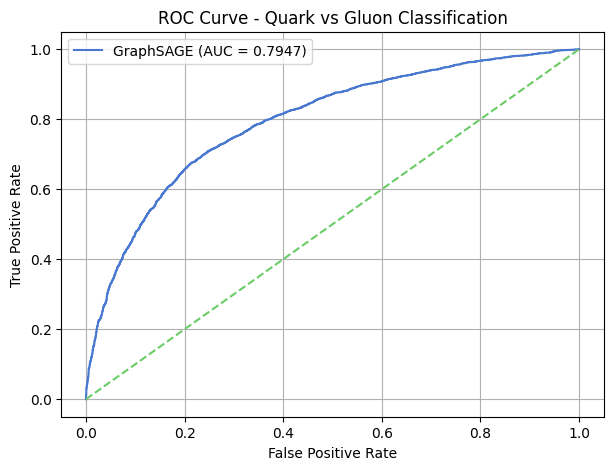

In [ ]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"GraphSAGE (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Quark vs Gluon Classification")
plt.legend()
plt.grid(True)
plt.show()

**Our curve sitting well above it confirms the model has learned meaningful discriminating features from the jet topology.**

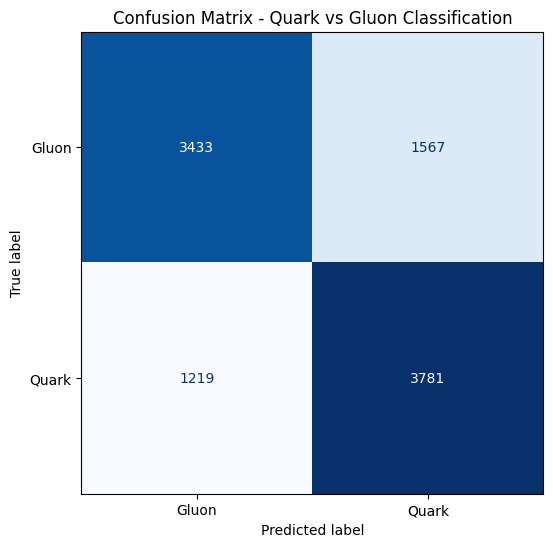

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# convert probabilities to class predictions
test_preds = (np.array(test_probs) >= 0.5).astype(int)

# confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Gluon", "Quark"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Quark vs Gluon Classification")
plt.show()

**The model is better at identifying quarks (75.6%) than gluons (68.7%).**

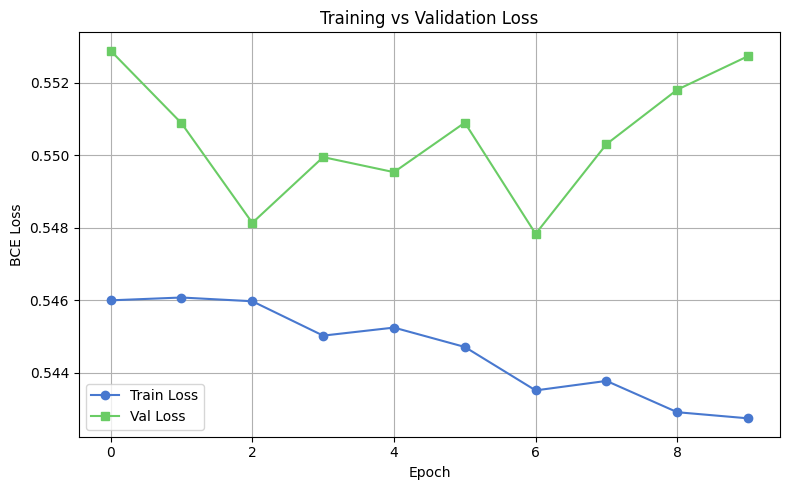

In [ ]:
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    # Changed plt.hist to plt.plot for plotting loss curves over epochs
    plt.plot(train_losses, label="Train Loss", marker="o")
    plt.plot(val_losses, label="Val Loss", marker="s")
    plt.xlabel("Epoch")
    plt.ylabel("BCE Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_loss(train_losses, val_losses)

### Results Summary & Discussion

| Metric | Value |
|---|---|
| Test ROC-AUC | **0.7912** |
| Final train loss | 0.5553 |
| Final val loss | 0.5508 |
| Epochs | 10 |
| Test samples | 10,000 |

**What worked well:**
- The **kNN graph construction** in (η, φ) position space is physically motivated — nearby calorimeter deposits often originate from the same sub-jet, so local message passing is meaningful
- **GraphSAGE** handles variable-size graphs naturally — jets range from very few to hundreds of active pixels, and the inductive aggregation scheme adapts without any padding
- **Global mean pooling** aggregates all node embeddings into a fixed-size jet representation in a permutation-invariant way, as required for set-like inputs

**Limitations & possible improvements:**
- **Edge features**: the current edges carry no attributes — adding Euclidean distance or ΔR as an edge weight could give the model explicit geometric information
- **More epochs / learning rate schedule**: the loss was still slowly decreasing at epoch 10
- **Richer node features**: adding `pt`, `m0`, or relative angular coordinates (Δη, Δφ from the jet axis) as node features would give the model more physics-aware inputs
- **Architecture depth**: trying **GIN** (Graph Isomorphism Network) or **GAT** (Graph Attention Network) could improve performance — GAT in particular can learn which neighbours are most relevant rather than treating all edges equally
- **Dynamic graph**: re-building the kNN graph in latent space at each layer (DGCNN-style) has shown strong results in jet classification tasks
